# Kommentar-Emotion Vergleich

Dieses Notebook wertet die berechneten Kommentar-Emotionen aus.


In [11]:
from pathlib import Path
from math import sqrt

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import chi2_contingency, kruskal, mannwhitneyu, spearmanr

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

COLOR_AI = "#2A9D8F"
COLOR_REAL = "#B85C7A"
PALETTE = {"VI": COLOR_AI, "RI": COLOR_REAL}
TYPE_LABELS = {"KI": "VI", "Real": "RI", "VI": "VI", "RI": "RI"}
TYPE_NOTE = "VI = AI-generierte Videos; RI = reale Videos"


def cohens_d(group_a, group_b):
    a = pd.Series(group_a).dropna().to_numpy()
    b = pd.Series(group_b).dropna().to_numpy()
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    return (a.mean() - b.mean()) / sqrt(pooled_var) if pooled_var > 0 else np.nan


def p_text(p_value):
    return "signifikant" if pd.notna(p_value) and p_value < 0.05 else "nicht signifikant"


def d_interpretation(d_value):
    if pd.isna(d_value):
        return "nicht bestimmbar"
    abs_d = abs(d_value)
    if abs_d < 0.2:
        return "vernachlässigbar klein"
    if abs_d < 0.5:
        return "klein"
    if abs_d < 0.8:
        return "mittel"
    return "groß"


def rho_interpretation(rho_value):
    abs_rho = abs(rho_value)
    if abs_rho < 0.1:
        return "praktisch kein Zusammenhang"
    if abs_rho < 0.3:
        return "schwacher Zusammenhang"
    if abs_rho < 0.5:
        return "mittlerer Zusammenhang"
    return "starker Zusammenhang"



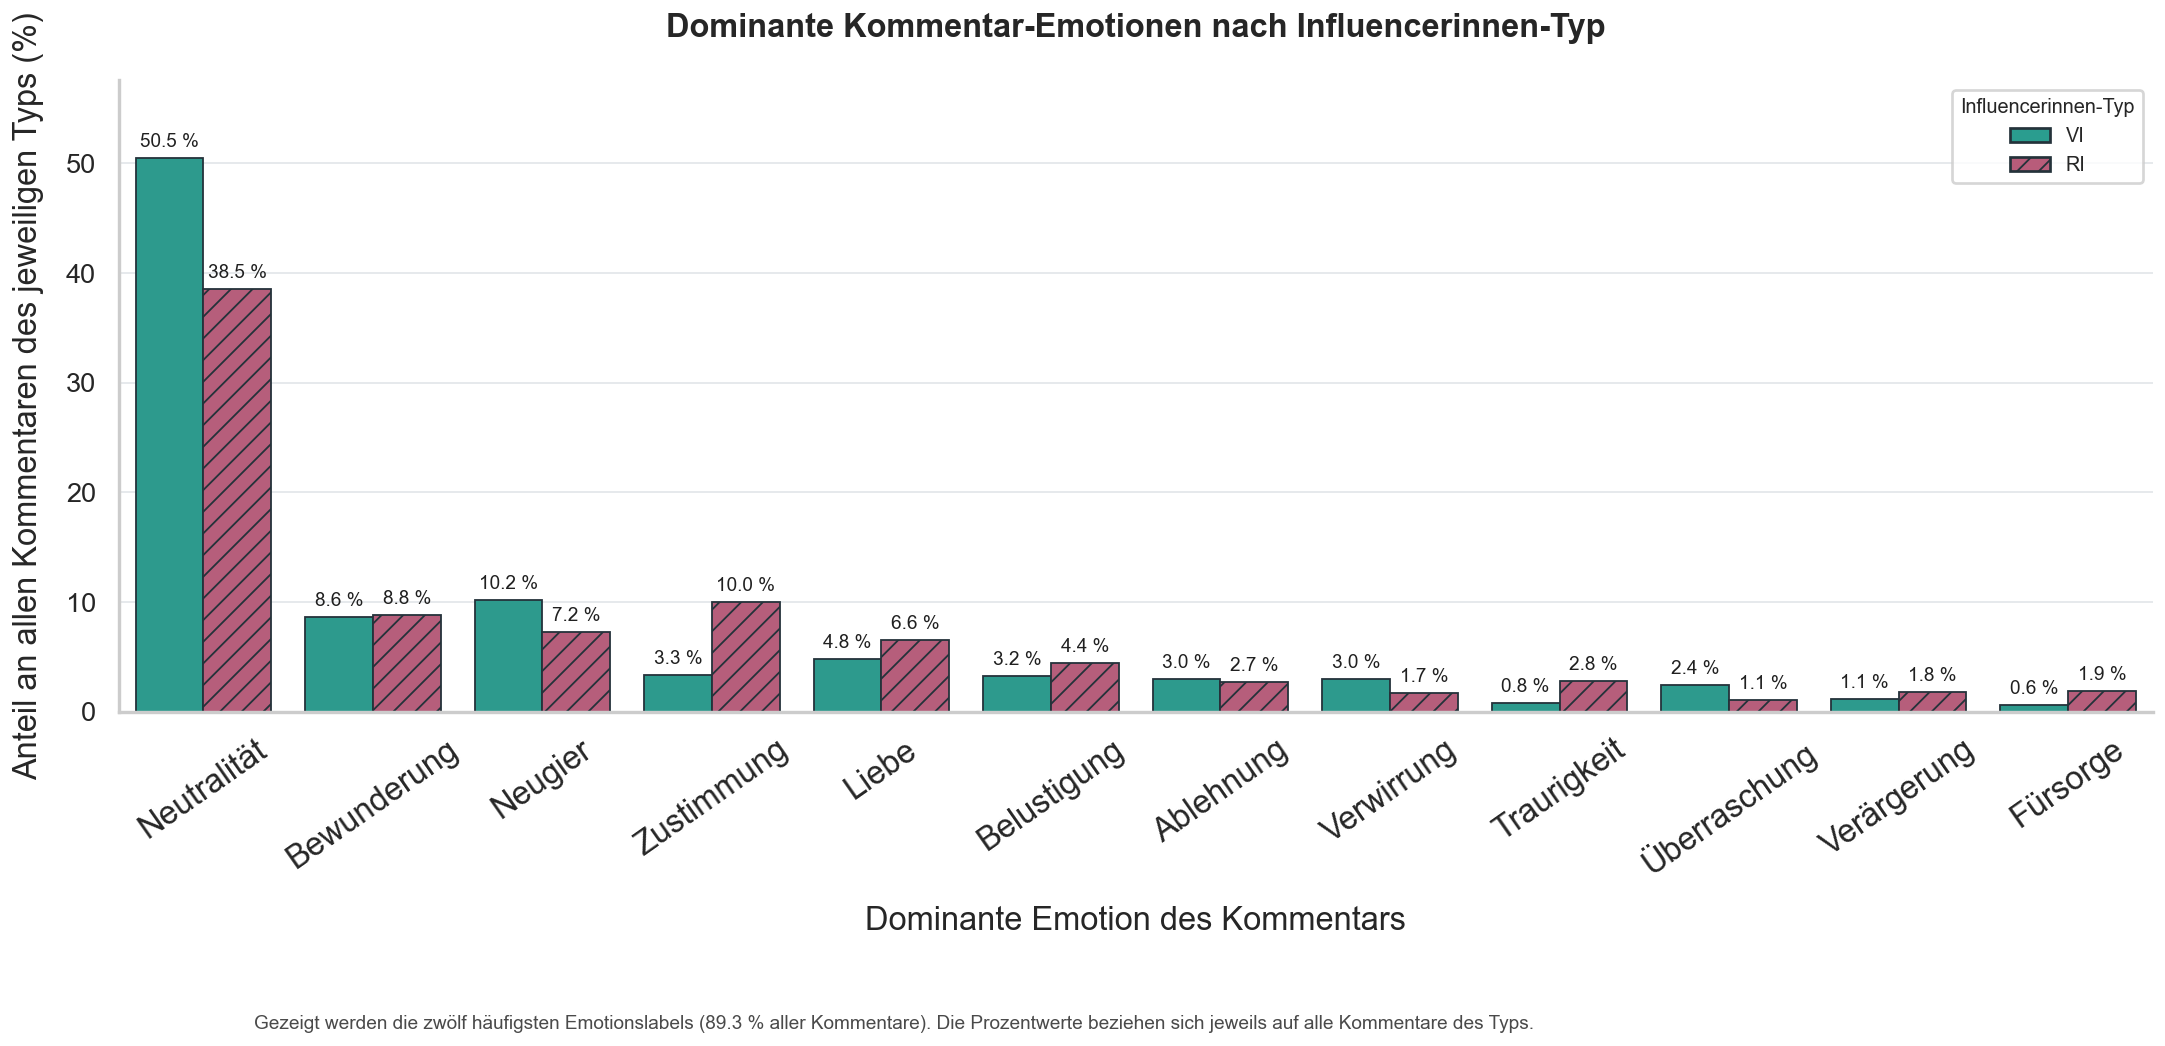

In [12]:
# Dominante Kommentar-Emotionen: direkter Vergleich der Influencerinnen-Typen
emotion_labels_de = {
    "neutral": "Neutralität",
    "admiration": "Bewunderung",
    "curiosity": "Neugier",
    "approval": "Zustimmung",
    "love": "Liebe",
    "amusement": "Belustigung",
    "disapproval": "Ablehnung",
    "confusion": "Verwirrung",
    "sadness": "Traurigkeit",
    "surprise": "Überraschung",
    "annoyance": "Verärgerung",
    "caring": "Fürsorge",
}

comment_results_path = Path.cwd().resolve().parents[1] / "comments" / "results" / "03_comment_emotion_results.csv"
comments_df = pd.read_csv(comment_results_path)
comments_df["Typ_plot"] = comments_df["Typ"].map(TYPE_LABELS).fillna(comments_df["Typ"])
label_share_df = comments_df.groupby(["Typ_plot", "comment_emotion_label"]).size().rename("Anzahl").reset_index()
label_share_df["Anteil_prozent"] = label_share_df.groupby("Typ_plot")["Anzahl"].transform(lambda s: 100 * s / s.sum())

top_emotions = comments_df["comment_emotion_label"].value_counts().nlargest(12).index
emotion_comparison = (
    label_share_df[label_share_df["comment_emotion_label"].isin(top_emotions)]
    .pivot(index="comment_emotion_label", columns="Typ_plot", values="Anteil_prozent")
    .reindex(top_emotions)
    .fillna(0)
)
coverage = 100 * comments_df["comment_emotion_label"].isin(top_emotions).mean()

plot_df = (
    emotion_comparison.reset_index()
    .melt(id_vars="comment_emotion_label", value_vars=["VI", "RI"], var_name="Typ_plot", value_name="Anteil_prozent")
)
plot_df["Emotion_de"] = plot_df["comment_emotion_label"].map(emotion_labels_de).fillna(plot_df["comment_emotion_label"])
emotion_order_de = [emotion_labels_de.get(label, label) for label in emotion_comparison.index]

fig, ax = plt.subplots(figsize=(17, 8.5))
sns.barplot(
    data=plot_df,
    x="Emotion_de",
    y="Anteil_prozent",
    hue="Typ_plot",
    order=emotion_order_de,
    hue_order=["VI", "RI"],
    palette=PALETTE,
    saturation=0.95,
    edgecolor="#24323A",
    linewidth=1.0,
    ax=ax,
)

for container, hatch in zip(ax.containers, ["", "//"]):
    for bar in container:
        bar.set_hatch(hatch)
    ax.bar_label(container, fmt="%.1f %%", padding=4, fontsize=10.5, color="#202020")

ax.set_ylim(0, emotion_comparison.to_numpy().max() * 1.14)
ax.set_title("Dominante Kommentar-Emotionen nach Influencerinnen-Typ", pad=24, weight="semibold")
ax.set_xlabel("Dominante Emotion des Kommentars", labelpad=14)
ax.set_ylabel("Anteil an allen Kommentaren des jeweiligen Typs (%)", labelpad=12)
ax.tick_params(axis="x", labelsize=18, rotation=35)
ax.tick_params(axis="y", labelsize=15)
ax.grid(axis="y", color="#E1E4E8", linewidth=0.9)
ax.grid(axis="x", visible=False)

legend_handles = [
    Patch(facecolor=COLOR_AI, edgecolor="#24323A", label="VI"),
    Patch(facecolor=COLOR_REAL, edgecolor="#24323A", hatch="//", label="RI"),
]
ax.legend(handles=legend_handles, title="Influencerinnen-Typ", frameon=True, loc="upper right", fontsize=11, title_fontsize=11)
fig.text(
    0.125,
    0.045,
    f"Gezeigt werden die zwölf häufigsten Emotionslabels ({coverage:.1f} % aller Kommentare). Die Prozentwerte beziehen sich jeweils auf alle Kommentare des Typs.",
    ha="left",
    va="bottom",
    fontsize=10.5,
    color="#4A4A4A",
)
#fig.text(0.01, 0.01, TYPE_NOTE, ha="left", va="bottom", fontsize=10, color="#5A5A5A")
sns.despine(ax=ax, top=True, right=True)
plt.tight_layout(rect=(0, 0.10, 1, 1))
plt.show()


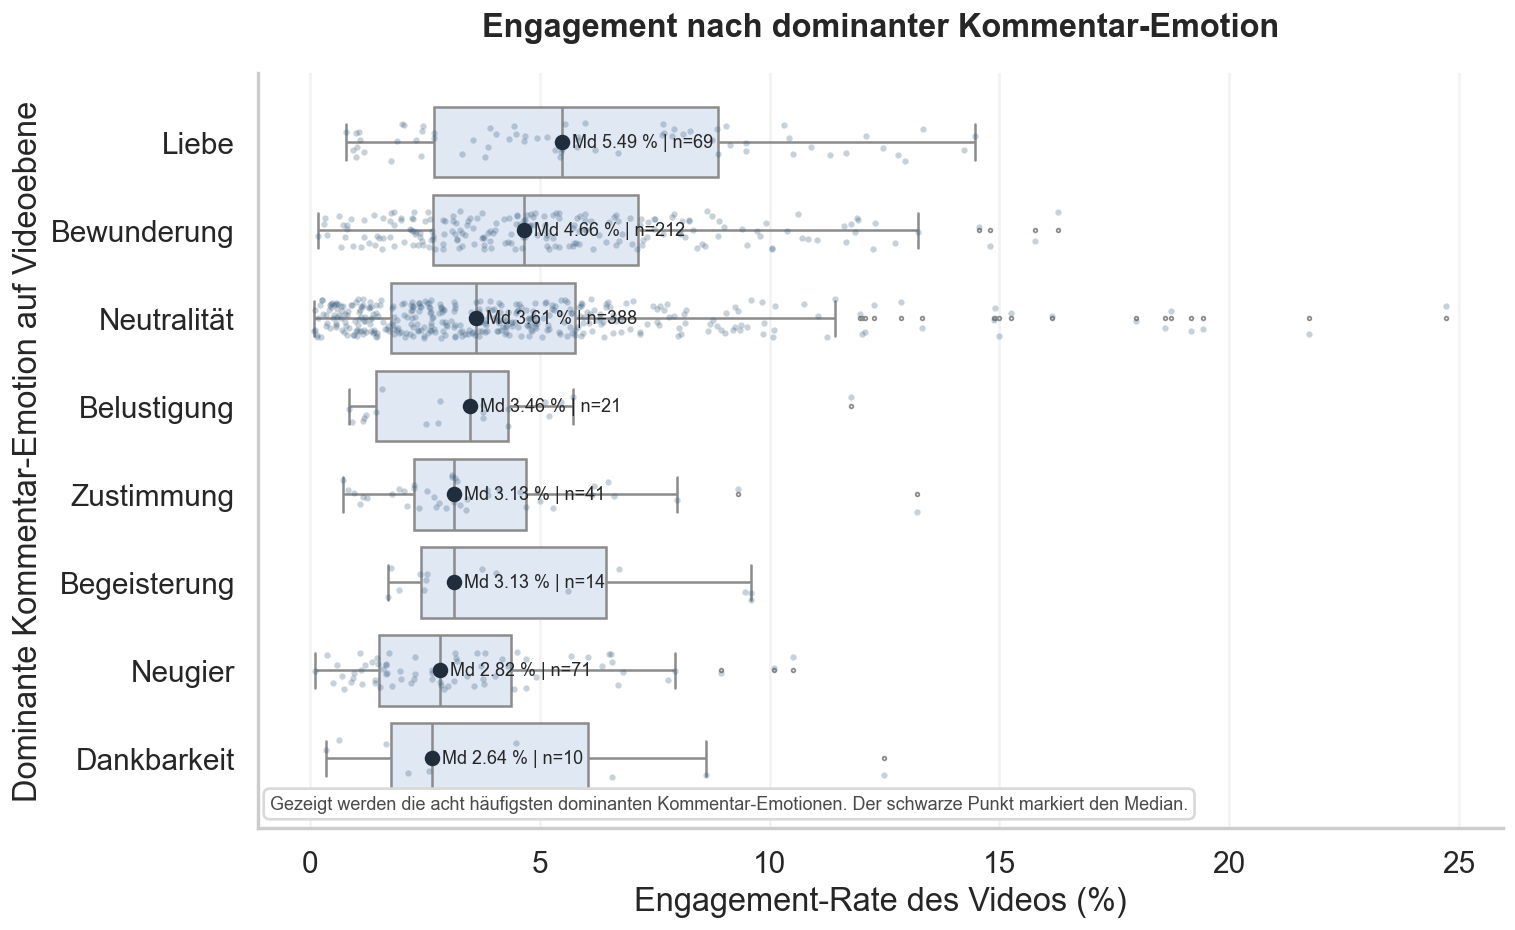

In [13]:
# Eigenständige Abbildung: Engagement nach dominanter Kommentar-Emotion (gesamt)
emotion_labels_de = {
    "neutral": "Neutralität",
    "admiration": "Bewunderung",
    "curiosity": "Neugier",
    "love": "Liebe",
    "approval": "Zustimmung",
    "amusement": "Belustigung",
    "excitement": "Begeisterung",
    "gratitude": "Dankbarkeit",
}

video_level_path = Path.cwd().resolve().parents[1] / "comments" / "results" / "03_comment_emotion_video_level.csv"
video_level_df = pd.read_csv(video_level_path)

engagement_emotion_df = video_level_df.dropna(
    subset=["dominant_comment_emotion", "video_engagement_rate"]
).copy()
top_emotions = engagement_emotion_df["dominant_comment_emotion"].value_counts().nlargest(8).index
engagement_emotion_df = engagement_emotion_df[
    engagement_emotion_df["dominant_comment_emotion"].isin(top_emotions)
].copy()
engagement_emotion_df["dominante_emotion_de"] = engagement_emotion_df["dominant_comment_emotion"].map(
    emotion_labels_de
).fillna(engagement_emotion_df["dominant_comment_emotion"])
engagement_emotion_df["Engagement_prozent"] = 100 * engagement_emotion_df["video_engagement_rate"]

emotion_order_raw = (
    engagement_emotion_df.groupby("dominant_comment_emotion")["Engagement_prozent"]
    .median()
    .sort_values(ascending=False)
    .index
    .tolist()
)
emotion_order = [emotion_labels_de.get(label, label) for label in emotion_order_raw]

fig, ax = plt.subplots(figsize=(12, 7.5))
sns.boxplot(
    data=engagement_emotion_df,
    x="Engagement_prozent",
    y="dominante_emotion_de",
    order=emotion_order,
    color="#DCE7F6",
    linewidth=1.4,
    fliersize=2,
    ax=ax,
)
sns.stripplot(
    data=engagement_emotion_df,
    x="Engagement_prozent",
    y="dominante_emotion_de",
    order=emotion_order,
    color="#355C7D",
    alpha=0.28,
    size=3.5,
    jitter=0.22,
    ax=ax,
)

medians = (
    engagement_emotion_df.groupby("dominante_emotion_de")["Engagement_prozent"]
    .median()
    .reindex(emotion_order)
)
counts = engagement_emotion_df["dominante_emotion_de"].value_counts().reindex(emotion_order)
for y, label in enumerate(emotion_order):
    median = medians.loc[label]
    n = int(counts.loc[label])
    ax.scatter(median, y, color="#1F2D3D", s=50, zorder=4)
    ax.text(median, y, f"  Md {median:.2f} % | n={n}", va="center", fontsize=10)

ax.set_title("Engagement nach dominanter Kommentar-Emotion", pad=20, weight="semibold")
ax.set_xlabel("Engagement-Rate des Videos (%)")
ax.set_ylabel("Dominante Kommentar-Emotion auf Videoebene")
ax.grid(axis="x", alpha=0.25)
ax.grid(axis="y", visible=False)
ax.text(
    0.01,
    0.02,
    "Gezeigt werden die acht häufigsten dominanten Kommentar-Emotionen. Der schwarze Punkt markiert den Median.",
    transform=ax.transAxes,
    va="bottom",
    fontsize=10,
    color="#4A4A4A",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D9D9D9"},
)

output_dir = Path.cwd().resolve().parents[1] / "outputs" / "figures" / "appendix"
output_dir.mkdir(parents=True, exist_ok=True)
for ext in ["png", "pdf", "svg"]:
    fig.savefig(output_dir / f"app_engagement_nach_dominanter_kommentaremotion.{ext}", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()



In [14]:
BASE_DIR = Path.cwd().resolve().parents[1]
COMMENT_RESULTS_CSV = BASE_DIR / "comments" / "results" / "03_comment_emotion_results.csv"
VIDEO_LEVEL_CSV = BASE_DIR / "comments" / "results" / "03_comment_emotion_video_level.csv"



In [15]:
comments_df = pd.read_csv(COMMENT_RESULTS_CSV)
video_level_df = pd.read_csv(VIDEO_LEVEL_CSV)
comments_df["Typ_plot"] = comments_df["Typ"].map(TYPE_LABELS).fillna(comments_df["Typ"])
video_level_df["Typ_plot"] = video_level_df["Typ"].map(TYPE_LABELS).fillna(video_level_df["Typ"])

required_comment_cols = {"Typ", "comment_id", "comment_emotion_label", "comment_emotion_unique_labels"}
required_video_cols = {"video_id", "Typ", "video_engagement_rate", "comment_count", "emotion_unique_labels_mean", "dominant_comment_emotion"}
missing_comment = required_comment_cols - set(comments_df.columns)
missing_video = required_video_cols - set(video_level_df.columns)
if missing_comment or missing_video:
    raise ValueError(
        "Die exportierten Emotionsdateien passen nicht zur aktuellen Comparison-Logik. "
        f"Fehlende Kommentarspalten: {sorted(missing_comment)} | Fehlende Video-Spalten: {sorted(missing_video)}. "
        "Bitte zuerst 03_comment_emotion.ipynb neu ausführen."
    )

comment_group_summary = (
    comments_df.groupby("Typ")
    .agg(
        n=("comment_id", "count"),
        emotion_unique_labels_M=("comment_emotion_unique_labels", "mean"),
        emotion_unique_labels_SD=("comment_emotion_unique_labels", "std"),
        emotion_unique_labels_Md=("comment_emotion_unique_labels", "median"),
    )
    .round(4)
    .reset_index()
)

ki_comments = comments_df.loc[comments_df["Typ"] == "KI", "comment_emotion_unique_labels"]
real_comments = comments_df.loc[comments_df["Typ"] == "Real", "comment_emotion_unique_labels"]
comment_u, comment_p = mannwhitneyu(ki_comments, real_comments, alternative="two-sided")
comment_d = cohens_d(ki_comments, real_comments)

label_share_df = comments_df.groupby(["Typ_plot", "comment_emotion_label"]).size().rename("Anzahl").reset_index()
label_share_df["Anteil_prozent"] = label_share_df.groupby("Typ_plot")["Anzahl"].transform(lambda s: 100 * s / s.sum())
ct = pd.crosstab(comments_df["Typ"], comments_df["comment_emotion_label"])
chi2, chi2_p, chi2_df, _ = chi2_contingency(ct)

video_group_summary = (
    video_level_df.groupby("Typ")
    .agg(
        Videos=("video_id", "count"),
        Kommentare_M=("comment_count", "mean"),
        emotion_unique_labels_M=("emotion_unique_labels_mean", "mean"),
        emotion_unique_labels_Md=("emotion_unique_labels_mean", "median"),
    )
    .round(4)
    .reset_index()
)

video_corr_df = video_level_df.dropna(subset=["video_engagement_rate", "emotion_unique_labels_mean"]).copy()
rho_all, p_all = spearmanr(video_corr_df["emotion_unique_labels_mean"], video_corr_df["video_engagement_rate"], nan_policy="omit")

engagement_label_df = video_corr_df.copy()
label_counts = engagement_label_df["dominant_comment_emotion"].value_counts()
valid_labels = label_counts[label_counts >= 2].index
engagement_label_df = engagement_label_df[engagement_label_df["dominant_comment_emotion"].isin(valid_labels)].copy()
if engagement_label_df["dominant_comment_emotion"].nunique() >= 2:
    groups = [group["video_engagement_rate"].dropna() for _, group in engagement_label_df.groupby("dominant_comment_emotion")]
    kw_stat, kw_p = kruskal(*groups)
else:
    kw_stat, kw_p = np.nan, np.nan

display(comment_group_summary)
display(video_group_summary)



,Typ,n,emotion_unique_labels_M,emotion_unique_labels_SD,emotion_unique_labels_Md
0,KI,14576,1.9724,0.9588,2.0
1,Real,18095,2.1719,0.9947,2.0


,Typ,Videos,Kommentare_M,emotion_unique_labels_M,emotion_unique_labels_Md
0,KI,238,61.2437,1.9571,1.9496
1,Real,640,28.2734,2.0432,2.0000


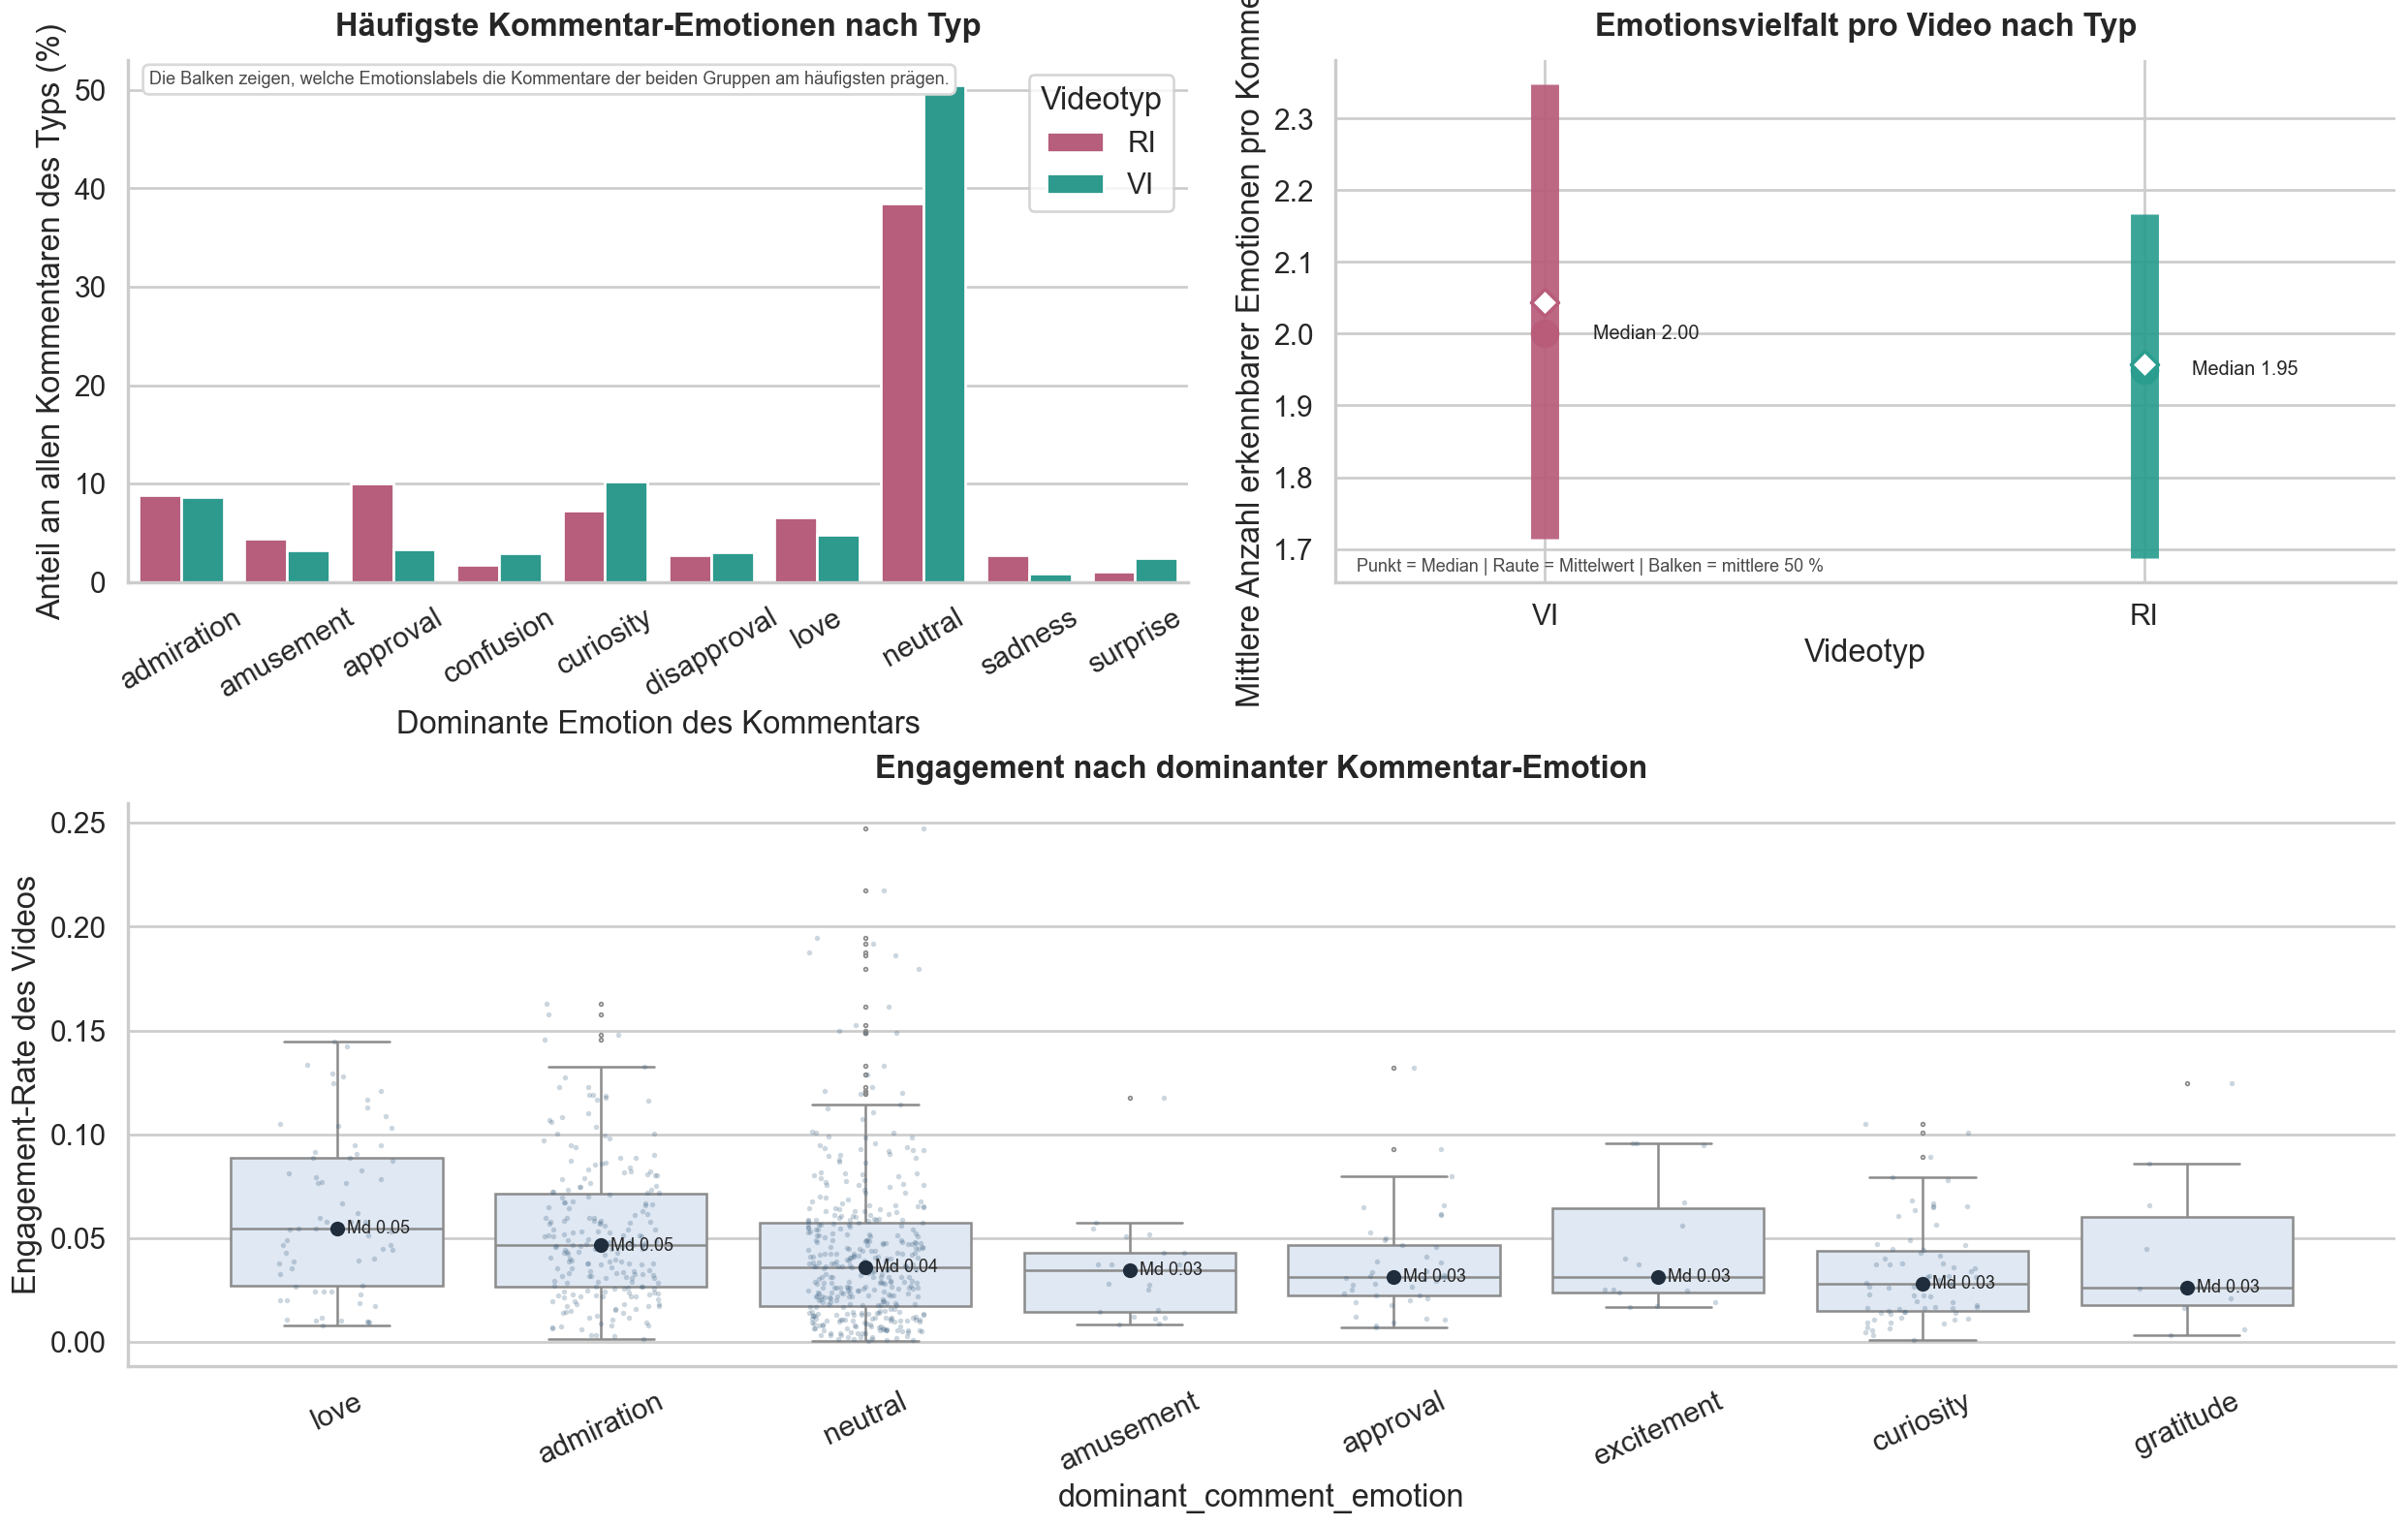

In [ ]:
fig = plt.figure(figsize=(19, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.08])
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :])

plot_df = label_share_df.copy()
top_labels = plot_df.groupby("comment_emotion_label")["Anzahl"].sum().nlargest(10).index
plot_df = plot_df[plot_df["comment_emotion_label"].isin(top_labels)]
sns.barplot(
    data=plot_df,
    x="comment_emotion_label",
    y="Anteil_prozent",
    hue="Typ_plot",
    palette=PALETTE,
    saturation=0.95,
    ax=ax1,
)
ax1.set_title("Häufigste Kommentar-Emotionen nach Typ", pad=14, weight="semibold")
ax1.set_xlabel("Dominante Emotion des Kommentars")
ax1.set_ylabel("Anteil an allen Kommentaren des Typs (%)")
ax1.tick_params(axis="x", rotation=30)
ax1.legend(title="Videotyp", frameon=True)
ax1.text(
    0.02,
    0.98,
    "Die Balken zeigen, welche Emotionslabels die Kommentare der beiden Gruppen am häufigsten prägen.",
    transform=ax1.transAxes,
    va="top",
    fontsize=10,
    color="#4A4A4A",
    bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": "#D9D9D9"},
)

summary_plot_df = (
    video_level_df.groupby("Typ_plot")["emotion_unique_labels_mean"]
    .agg(Q1=lambda s: s.quantile(0.25), Median="median", Q3=lambda s: s.quantile(0.75), Mittelwert="mean")
    .reset_index()
)
for x, row in enumerate(summary_plot_df.to_dict("records")):
    ax2.vlines(x, row["Q1"], row["Q3"], color=PALETTE[row["Typ_plot"]], linewidth=16, alpha=0.92)
    ax2.scatter(x, row["Median"], color=PALETTE[row["Typ_plot"]], s=220, zorder=3)
    ax2.scatter(x, row["Mittelwert"], color="white", edgecolor=PALETTE[row["Typ_plot"]], linewidth=2, marker="D", s=120, zorder=4)
    ax2.text(x + 0.08, row["Median"], f"Median {row['Median']:.2f}", va="center", fontsize=11)
ax2.set_xticks([0, 1], ["VI", "RI"])
ax2.set_xlim(-0.35, 1.42)
ax2.set_title("Emotionsvielfalt pro Video nach Typ", pad=14, weight="semibold")
ax2.set_xlabel("Videotyp")
ax2.set_ylabel("Mittlere Anzahl erkennbarer Emotionen pro Kommentar")
ax2.text(0.02, 0.02, "Punkt = Median | Raute = Mittelwert | Balken = mittlere 50 %", transform=ax2.transAxes, fontsize=10, color="#4A4A4A")

engagement_plot_df = engagement_label_df.copy()
top_engagement_labels = engagement_plot_df["dominant_comment_emotion"].value_counts().nlargest(8).index
engagement_plot_df = engagement_plot_df[engagement_plot_df["dominant_comment_emotion"].isin(top_engagement_labels)]
order = engagement_plot_df.groupby("dominant_comment_emotion")["video_engagement_rate"].median().sort_values(ascending=False).index
sns.boxplot(
    data=engagement_plot_df,
    x="dominant_comment_emotion",
    y="video_engagement_rate",
    order=order,
    color="#DCE7F6",
    linewidth=1.4,
    fliersize=2,
    ax=ax3,
)
sns.stripplot(
    data=engagement_plot_df,
    x="dominant_comment_emotion",
    y="video_engagement_rate",
    order=order,
    color="#355C7D",
    alpha=0.25,
    size=3,
    jitter=0.22,
    ax=ax3,
)
medians = engagement_plot_df.groupby("dominant_comment_emotion")["video_engagement_rate"].median().reindex(order)
for x, (label, median) in enumerate(medians.items()):
    ax3.scatter(x, median, color="#1F2D3D", s=48, zorder=4)
    ax3.text(x, median, f"  Md {median:.2f}", va="center", fontsize=10)
ax3.set_title("Engagement nach dominanter Kommentar-Emotion", pad=14, weight="semibold")
ax3.set_ylabel("Engagement-Rate des Videos")
ax3.tick_params(axis="x", rotation=25)


plt.show()


In [7]:
ki_row = comment_group_summary.loc[comment_group_summary["Typ"] == "KI"].iloc[0]
real_row = comment_group_summary.loc[comment_group_summary["Typ"] == "Real"].iloc[0]
print(f"Kommentar-Level VI: n = {int(ki_row['n'])}, M = {ki_row['emotion_unique_labels_M']:.3f}, Md = {ki_row['emotion_unique_labels_Md']:.3f}")
print(f"Kommentar-Level RI: n = {int(real_row['n'])}, M = {real_row['emotion_unique_labels_M']:.3f}, Md = {real_row['emotion_unique_labels_Md']:.3f}")
print(f"Emotionsvielfalt auf Kommentar-Level: U = {comment_u:.2f}, p = {comment_p:.4f}. Der Unterschied ist {p_text(comment_p)}. Effektgröße: {d_interpretation(comment_d)} (d = {comment_d:.3f}).")
print(f"Verteilung der dominanten Emotionslabels: chi2 = {chi2:.2f}, df = {chi2_df}, p = {chi2_p:.4f}. Die Verteilung ist {p_text(chi2_p)} unterschiedlich.")
print(f"Emotionsvielfalt und Engagement: rho = {rho_all:.3f}, p = {p_all:.4f}. Der Befund ist {p_text(p_all)} und entspricht {rho_interpretation(rho_all)}.")
if pd.notna(kw_p):
    print(f"Dominante Kommentar-Emotion und Engagement: H = {kw_stat:.2f}, p = {kw_p:.4f}. Der Unterschied zwischen den Emotionskategorien ist {p_text(kw_p)}.")
else:
    print("Dominante Kommentar-Emotion und Engagement: Nicht auswertbar, weil zu wenige Kategorien mit mindestens zwei Videos vorlagen.")



Kommentar-Level VI: n = 14576, M = 1.972, Md = 2.000
Kommentar-Level RI: n = 18095, M = 2.172, Md = 2.000
Emotionsvielfalt auf Kommentar-Level: U = 117235286.00, p = 0.0000. Der Unterschied ist signifikant. Effektgröße: klein (d = -0.204).
Verteilung der dominanten Emotionslabels: chi2 = 2028.23, df = 26, p = 0.0000. Die Verteilung ist signifikant unterschiedlich.
Emotionsvielfalt und Engagement: rho = -0.007, p = 0.8311. Der Befund ist nicht signifikant und entspricht praktisch kein Zusammenhang.
Dominante Kommentar-Emotion und Engagement: H = 52.75, p = 0.0000. Der Unterschied zwischen den Emotionskategorien ist signifikant.
